In [1]:
import os
import cv2
import numpy as np

from skimage.feature import hog
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from datasets import load_dataset
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from tqdm import tqdm


def load_raf_db(dataset_path, img_size=(64,64), max_images_per_class=None):
    X, y = [], []
    labels = sorted(os.listdir(dataset_path))

    for label_idx, label in enumerate(labels):
        label_path = os.path.join(dataset_path, label)
        if not os.path.isdir(label_path):
            continue

        images = os.listdir(label_path)
        if max_images_per_class:
            images = images[:max_images_per_class]

        for img_name in tqdm(images, desc=f"Cargando {label}"):
            img_path = os.path.join(label_path, img_name)
            img = cv2.imread(img_path)

            if img is None:
                continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) ##Pasamos a blanco y negro
            face = cv2.resize(gray, img_size)##Resize a 64
            face = face / 255.0 ##Normalizamos

            features = hog(
                face,
                orientations=9,
                pixels_per_cell=(8,8),
                cells_per_block=(2,2),
                block_norm="L2-Hys"
            )

            X.append(features)
            y.append(label_idx)

    return np.array(X), np.array(y), labels

/home/lidgon02/ViT/hog_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_path = "../RAF_DB/DATASET/train"
test_path = "../RAF_DB/DATASET/test"
IMG_SIZE = 64

X1, y1, labels = load_raf_db(train_path, img_size=(IMG_SIZE, IMG_SIZE))
X2, y2, _      = load_raf_db(test_path,  img_size=(IMG_SIZE, IMG_SIZE))


Cargando surprise: 100%|██████████| 329/329 [00:00<00:00, 836.89it/s]


In [3]:
X_test = X2
y_test = y2
X_train = X1
y_train = y1
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (12271, 1764)
Test: (3068, 1764)


In [4]:
import numpy as np

def contar_por_etiqueta(y, labels, nombre_split="Dataset"):
    unique, counts = np.unique(y, return_counts=True)
    print(f"\n{nombre_split}:")
    for label_idx, count in zip(unique, counts):
        print(f"{labels[label_idx]}: {count} muestras")

# Contar en cada split
contar_por_etiqueta(y_train, labels, "Train")
contar_por_etiqueta(y_test,  labels, "Test")


Train:
anger: 705 muestras
disgust: 717 muestras
fear: 281 muestras
happy: 4772 muestras
neutral: 2524 muestras
sad: 1982 muestras
surprise: 1290 muestras

Test:
anger: 162 muestras
disgust: 160 muestras
fear: 74 muestras
happy: 1185 muestras
neutral: 680 muestras
sad: 478 muestras
surprise: 329 muestras


In [5]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
                class_weight="balanced",
                cache_size=2000))
])

In [6]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "svm__C": [0.1, 1, 10, 100, 1000],
    "svm__gamma": [0.001, 0.01, 0.1, 1],
    "svm__kernel": ["rbf"]
}
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=15,
    cv=3,
    scoring="f1_macro",
    verbose=2,
    n_jobs=-1,
    random_state=16
)


In [7]:
random_search.fit(X_train, y_train)


Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END ......svm__C=100, svm__gamma=0.001, svm__kernel=rbf; total time=18.5min
[CV] END ......svm__C=100, svm__gamma=0.001, svm__kernel=rbf; total time=18.9min
[CV] END .....svm__C=1000, svm__gamma=0.001, svm__kernel=rbf; total time=18.9min
[CV] END .....svm__C=1000, svm__gamma=0.001, svm__kernel=rbf; total time=18.9min
[CV] END ......svm__C=100, svm__gamma=0.001, svm__kernel=rbf; total time=19.0min
[CV] END .....svm__C=1000, svm__gamma=0.001, svm__kernel=rbf; total time=19.1min
[CV] END ..........svm__C=0.1, svm__gamma=1, svm__kernel=rbf; total time=21.4min
[CV] END ..........svm__C=100, svm__gamma=1, svm__kernel=rbf; total time=21.5min
[CV] END ............svm__C=1, svm__gamma=1, svm__kernel=rbf; total time=21.5min
[CV] END ..........svm__C=0.1, svm__gamma=1, svm__kernel=rbf; total time=21.6min
[CV] END ............svm__C=1, svm__gamma=1, svm__kernel=rbf; total time=21.6min
[CV] END ..........svm__C=0.1, svm__gamma=1, svm

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'svm__C': [0.1, 1, ...], 'svm__gamma': [0.001, 0.01, ...], 'svm__kernel': ['rbf']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",16
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``c

In [8]:
print("Mejores hiperparámetros:")
print(random_search.best_params_)


Mejores hiperparámetros:
{'svm__kernel': 'rbf', 'svm__gamma': 0.001, 'svm__C': 1}


In [9]:
from sklearn.metrics import accuracy_score, classification_report, balanced_accuracy_score, f1_score

model = random_search.best_estimator_
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred, target_names=labels))


Accuracy: 0.7121903520208605
Balanced Accuracy: 0.5593917917211472
Macro F1: 0.5858976245670984
              precision    recall  f1-score   support

       anger       0.66      0.55      0.60       162
     disgust       0.45      0.18      0.26       160
        fear       0.95      0.27      0.42        74
       happy       0.87      0.84      0.85      1185
     neutral       0.61      0.79      0.69       680
         sad       0.58      0.64      0.61       478
    surprise       0.69      0.65      0.67       329

    accuracy                           0.71      3068
   macro avg       0.69      0.56      0.59      3068
weighted avg       0.72      0.71      0.70      3068



In [10]:
import joblib
joblib.dump(model, "hog_svm_baseline.pkl")

['hog_svm_baseline.pkl']

In [11]:
import time
import numpy as np

# X_test es tu conjunto de prueba
start = time.time()
y_pred = model.predict(X_test)
end = time.time()

total_time = end - start
avg_time_per_sample = total_time / X_test.shape[0]

print(f"Tiempo total de predicción: {total_time:.4f} s")
print(f"Tiempo promedio por muestra: {avg_time_per_sample*1000:.4f} ms")

Tiempo total de predicción: 42.7203 s
Tiempo promedio por muestra: 13.9245 ms


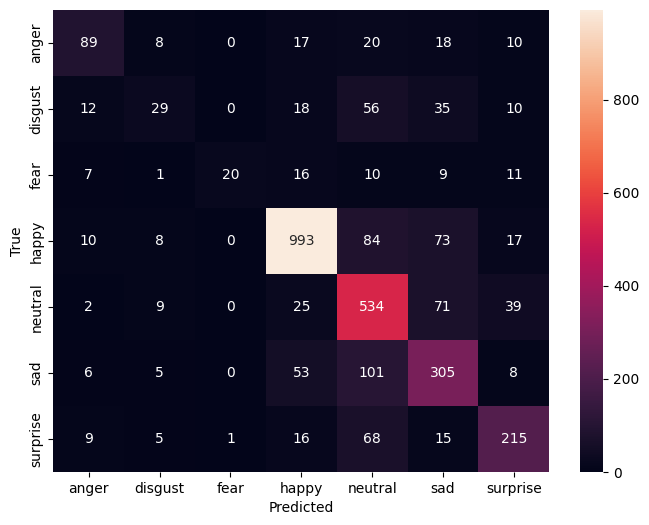

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()